<a href="https://colab.research.google.com/github/lutfikhamami/llm_engineering/blob/latihan/practice_day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Welcome to Pipelines!
The HuggingFace transformers library provides APIs at two different levels.

The High Level API for using open-source models for typical inference tasks is called "pipelines". It's incredibly easy to use.

You create a pipeline using something like:

my_pipeline = pipeline("the_task_I_want_to_do")

Followed by

result = my_pipeline(my_input)

And that's it!

See end of this colab for a list of all pipelines.

## Before we start: 2 important pro-tips for using Colab:

**Pro-tip 1:**

Data Science code often gives warnings and messages. They can mostly be safely ignored! Glance over them, and if something goes wrong later, perhaps they can give you a clue.

**Pro-tip 2:**

In the middle of running a Colab, you might get an error like this:

> Runtime error: CUDA is required but not available for bitsandbytes. Please consider installing [...]

This is a super-misleading error message! Please don't try changing versions of packages...

This actually happens because Google has switched out your Colab runtime, perhaps because Google Colab was too busy. The solution is:

1. Kernel menu >> Disconnect and delete runtime
2. Reload the colab from fresh and Edit menu >> Clear All Outputs
3. Connect to a new T4 using the button at the top right
4. Select "View resources" from the menu on the top right to confirm you have a GPU
5. Rerun the cells in the colab, from the top down, starting with the pip installs

And all should work great - otherwise, ask me!


## A sidenote:

You may already know this, but just in case you're not familiar with the word "inference" that I use here:

When working with Data Science models, you could be carrying out 2 very different activities: **training** and **inference**.

### 1. Training  

**Training** is when you provide a model with data for it to adapt to get better at a task in the future. It does this by updating its internal settings - the parameters or weights of the model. If you're Training a model that's already had some training, the activity is called "fine-tuning".

### 2. Inference

**Inference** is when you are working with a model that has _already been trained_. You are using that model to produce new outputs on new inputs, taking advantage of everything it learned while it was being trained. Inference is also sometimes referred to as "Execution" or "Running a model".

All of our use of APIs for GPT, Claude and Gemini in the last weeks are examples of **inference**. The "P" in GPT stands for "Pre-trained", meaning that it has already been trained with data (lots of it!) In week 6 we will try fine-tuning GPT ourselves.
  
The pipelines API in HuggingFace is only for use for **inference** - running a model that has already been trained. In week 7 we will be training our own model, and we will need to use the more advanced HuggingFace APIs that we look at in the up-coming lecture.

I recorded this playlist on YouTube with more on parameters, training and inference:  
https://www.youtube.com/playlist?list=PLWHe-9GP9SMMdl6SLaovUQF2abiLGbMjs


In [1]:
# pip installs should come at the top line
# if your Kernel ever resets, you need to run this again.


# ! = jalankan ini sebagai perintah terminal/shell
# pip install = perintah untuk install library python dari internet (PyPI, gudang package Python)
# -q = singkatan dari quiet, (diam, jangan tampilkan output)
# --upgrade = memaksa pip untuk menginstall ulang library, kalau sudah ada gunanya memastikan versi yang terinstall sesuai dengan yang di minta
# dataset==3.6.0 dan transformers==4.57.6 = dua library yang di instal dengan versi yang di lock, tanda (==) harus sama persis versinya "pinning a version"
# transformers = library utama Hugging Face, tempat fungsi pipeline()
# dataset = library untuk memuat data

# Kenapa versinya di lock ?
# karena library HF sering di update,dan kadang update bisa merusak code yang tadinya jalan(istilah: braking changes)
!pip install -q --upgrade datasets==3.6.0 transformers==4.57.6

In [6]:
# let's check the GPU - it should be a Tesla T4

gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)
  if gpu_info.find('Tesla T4') >= 0:
    print('Success - Connected to a T4')
  else:
    print('NOT CONNECT TO A T4')

Mon Aug  3 16:02:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   63C    P0             29W /   70W |    1425MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# Library yang di butuhkan

import torch # PyTorch, framework deep learning utama, mesin di balik semua model yang akan di jalankan, (import seluruh library torch)
from google.colab import userdata # modul colab untuk akses secrets token API HF
from huggingface_hub import login # fungsi login HF, masuk ke akun HF supaya bisa mengunduh model dari HF
from transformers import pipeline # fungsi pipeline(), high level API untuk menjalankan model teks (sentimen, NER, summarization, traslation, dll)
from diffusers import DiffusionPipeline # pipeline untuk diffusers models(model generate image seperti stable diffusion), transformers untuk teks/token, diffusers untuk image
from datasets import load_dataset # fungsi untuk membuat dataset siap-pakai dari HF hub, di notebook di pakai untuk mengambil speaker embeddings(data karakter suara)
import soundfile as sf # library untuk membaca/menulis file audio as sf, sf adalah singkatan "soundfile" di gunakan untuk mempersingkat penulisan
from IPython.display import Audio # Audio adalah untuk memutar audio langsung dalam notebook

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [5]:
hf_token = userdata.get('HF_TOKEN')
if hf_token and hf_token.startswith("hf_"):
    print('HF key looks good so far')
else:
    print('HF token is not set - please click the key in the left sidebar')
login(hf_token, add_to_git_credential=True)

HF key looks good so far


## Using Pipelines from Hugging Face

A simple way to run inference for common tasks, without worrying about all the plumbing, picking reasonable defaults.


### How it works:

STEP 1: Create a pipeline - a function you can then call

```python
my_pipeline = pipeline(task, model=xx, device=xx)
```

If you don't specify a model, then Hugging Face picks one for you that's the default for the task. Specify "cuda" for the device to use an NVIDIA GPU like the one on the T4. Specify "mps" on a Mac.


STEP 2: Then call it as many times as you want:

```python
my_pipeline(input1)
my_pipeline(input2)
```

In [6]:
# Sentiment Analysis
# dalam case ini tidak menyertakan model, HF otomatis memilihkan modelnya (distilbert/distilbert-base-uncased-finetuned-sst-2-english)
# menentukan task("sentimen analisis") -> model yang di pilih(HF) -> output mengikuti bentuk sesuai task -> label + score

my_simple_sentiment_analyzer = pipeline("sentiment-analysis", device="cuda") # membuat pipeline(sentiment-analysis = menilai kalimat itu positif atau negatif, device="cuda" = suruh pakai GPU(T-4 dalam colab)"cuda" adalah teknologi Nvidia untuk komputasi paralel di GPU, kalau lokal dalam mac ("mps"))
result = my_simple_sentiment_analyzer("I'm super excited to be on the way to LLM engineer") # memanggil pipeline(kalimat teks yang akan di analisa)
print(result) # panggil result dan tampilkan

# output pipeline selalu return dalam bentuk list [] walau isinya cuma satu
# Satu hal penting!
# tidak semua model bisa di pakai untuk semua task, setiap model di latih untuk jenis task/pekerjaan tertentu,
# makanya pada models HF model-model di kelompokkan bedasarkan task, pilih model yang memang di training untuk task tersebut/translation, jika menggunakan model yang salah dengan task, hasilnya error atau outputnya tidak sesuai

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cuda


[{'label': 'POSITIVE', 'score': 0.999107301235199}]


In [7]:
result = my_simple_sentiment_analyzer("I should be more excited to be on the way to LLM enginer")
print(result)

[{'label': 'POSITIVE', 'score': 0.8885098695755005}]


In [11]:
# case ini menggunakan model pilihan sendiri

better_sentiment = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment", device="cuda", top_k=None) # top_k=None(menuruh model menampilkan semua label beserta skornya)
result = better_sentiment("I should be more excited to be on the way to LLM engineer")
print(result)

# model memberi label dengan rating star berbeda dengan model sebelumnya yang melabeli positif/negatif
# model memberi 2 star yang artinya model ragu (kalimat tersebut bernada kurang antusias atau ambigu)

Device set to use cuda


[[{'label': '2 stars', 'score': 0.4067052900791168}, {'label': '3 stars', 'score': 0.3669462203979492}, {'label': '1 star', 'score': 0.1411995142698288}, {'label': '4 stars', 'score': 0.06508774310350418}, {'label': '5 stars', 'score': 0.020061219111084938}]]


In [12]:
# Ner = Named Entity Recognetion, task : membaca kalimat lalu menandai dengan kata-kata mana yang merupakan "entitas"-nama orang, organisasi, tempat, dll
# Kategori entitas utama pada output:
# PER = Person(orang) -> "ed donner"
# ORG = Organization(organisasi/perusahaan) -> AI Engineer
# MISC = Miscellaneous(lain-lain, yang tidak masuk kategori jelas) -> Hugging Face, Google Colab
# LOC = Location(lokasi) -> tempat

ner = pipeline("ner", device="cuda")
result = ner("AI Engineers are learning about the amazing pipelines from Hugging Face in Google Colab from Ed Donner")
print(result)

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496 (https://huggingface.co/dbmdz/bert-large-cased-finetuned-conll03-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cuda


[{'entity': 'I-ORG', 'score': np.float32(0.99943215), 'index': 1, 'word': 'AI', 'start': 0, 'end': 2}, {'entity': 'I-ORG', 'score': np.float32(0.9941089), 'index': 2, 'word': 'Engineers', 'start': 3, 'end': 12}, {'entity': 'I-MISC', 'score': np.float32(0.42179328), 'index': 12, 'word': '##gging', 'start': 61, 'end': 66}, {'entity': 'I-MISC', 'score': np.float32(0.6019917), 'index': 13, 'word': 'Face', 'start': 67, 'end': 71}, {'entity': 'I-MISC', 'score': np.float32(0.8506552), 'index': 15, 'word': 'Google', 'start': 75, 'end': 81}, {'entity': 'I-MISC', 'score': np.float32(0.7174734), 'index': 16, 'word': 'Cola', 'start': 82, 'end': 86}, {'entity': 'I-MISC', 'score': np.float32(0.6032837), 'index': 17, 'word': '##b', 'start': 86, 'end': 87}, {'entity': 'I-PER', 'score': np.float32(0.998904), 'index': 19, 'word': 'Ed', 'start': 93, 'end': 95}, {'entity': 'I-PER', 'score': np.float32(0.9987613), 'index': 20, 'word': 'Don', 'start': 96, 'end': 99}, {'entity': 'I-PER', 'score': np.float32(

In [14]:
# Langkah Menuju RAG
# Question Answering with Context
# Task menjawab pertanyaan, model tidak mengarang, jawaban dari pengetahuannya sendiri question dan context
# jika tidak konteks model tidak bisa menjawab atau model akan mengarang/halusinasi



question = "What are Hugging Face pipelines?"
context = "Pipelines are a high level API for interface of LLMs common tasks"

question_answerer = pipeline("question-answering", device="cuda") # menggunakan pipeline task "question-answering" di GPU dengan model default
result = question_answerer(question=question, context=context) # memanggil pipeline task berisi 2 argument (question dan context)
print(result)

# output:
# answer': 'high level API for interface of LLMs common tasks' -> potongan yang model ambil dari konteks sebagai jawaban, perhatikan jawabannya sama dengan konteks

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda


{'score': 0.40310075879096985, 'start': 16, 'end': 65, 'answer': 'high level API for interface of LLMs common tasks'}


In [16]:
# Text Summarization
# Task meringkas text panjang jadi pendek, mengambil poin-poin penting saja
# Task "summarization" memproduksi teks baru yang lebih ringkas

summarizer = pipeline("summarization", device="cuda")
text = """
The Hugging Face transformers library is an incredibly versatile and powerful tool for natural language processing (NLP).
It allows users to perform a wide range of tasks such as text classification, named entity recognition, and question answering, among others.
It's an extremely popular library that's widely used by the open-source data science community.
It lowers the barrier to entry into the field by providing Data Scientists with a productive, convenient way to work with transformer models.
"""

summary = summarizer(text, max_length=50, min_length=25, do_sample=False) # memanggil pipeline dengan 3 parameter tambahan(max_length(ringkas maksimal 50token), min_length(ringkas minimal 25token), do_sample=False(menyuruh model tidak memakai sampling/acak, model akan selalu memilih kata yang paling mungkin aman, hasilnya:deterministik, jika do_sample=True model akan sedikit kreatif/acak, bisa hasilnya beda tiap generate))
print(summary[0]['summary_text']) # mencetak hasilnya, ambil element pertama[0], ambil teks ringkasannya.
# jika print(summary) saja tanpa[0], maka ['summary_text'] akan memberikan struktur mentah

No model was supplied, defaulted to sshleifer/distilbart-cnn-12-6 and revision a4f8f3e (https://huggingface.co/sshleifer/distilbart-cnn-12-6).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda


 The Hugging Face transformers library is an incredibly versatile and powerful tool for natural language processing . It allows users to perform a wide range of tasks such as text classification, named entity recognition, and question answering .


In [17]:
# Translation
# Task translate inggris ke francis

translator = pipeline("translation_en_to_fr", device="cuda")
result = translator("The data scientists were truly amazed by the power and simplicity of the HuggingFace pipeline API")
print(result[0]['translation_text'])

No model was supplied, defaulted to google-t5/t5-base and revision a9723ea (https://huggingface.co/google-t5/t5-base).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda


Les chercheurs en données ont été vraiment étonnés par la puissance et la simplicité de l’API du pipeline HuggingFace


In [20]:
# Classification
# Task mengelompokkan teks ke dalam kategori(bucket), yang di tentukan sendiri ["technology", "sports", "politics"]
# zero-shot = "tanpa contoh"
# model tidak pernah di latih khusus untuk membedakan kategori "technology/sports/politics", kita tidak memberi satupun contoh, seperti bilang. "ini kalimatnya, ini pilihan kategorinya - tebak masuk yang mana", dan model bisa melakukannya langsung tanpa contoh, itula zero-shot: nol contoh di berikan
# berbeda dengan model sentimen(DistilBERT), model di latih khusus untuk POSITIF/NEGATIF



classifier = pipeline("zero-shot-classification", device="cuda")
result = classifier("Hugging Face's Transformers library is amazing!", candidate_labels=["technology", "sports", "politics"]) # memanggil pipeline dengan 2 parameter("kalimat yang mau di klasifikasi", daftar kategori sendiri(bucket))
print(result)

# output:
# dictionary berisi 3 bagia:
# 1. sequence: "kalimat klasifikasi"
# 2. labels: ['technolohy', 'sports', 'politics']
# 3. scores: skor keyakinan untuk tiap label, sejajar urutannya dengan "labels"

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1 (https://huggingface.co/facebook/bart-large-mnli).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda


{'sequence': "Hugging Face's Transformers library is amazing!", 'labels': ['technology', 'sports', 'politics'], 'scores': [0.9493839740753174, 0.03225007280707359, 0.018365919589996338]}


In [22]:
# Text Generation
# Task menghasilkan lanjutan teks seperti contoh memberi awalan kalimat(prompt), model melanjutkannya kata per kata
# Task inti yang di lakukan LLM seperti GPT/Claude
# Mode default: "openai-community/gpt2"


generator = pipeline("text-generation", device="cuda")
result = generator("if there's one thing i want you to remember about using HuggingFace pipelines, it's")
print(result[0]['generated_text'])

No model was supplied, defaulted to openai-community/gpt2 and revision 607a30d (https://huggingface.co/openai-community/gpt2).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


if there's one thing i want you to remember about using HuggingFace pipelines, it's that it's a very small system that makes it easy to do some of the things you need to do for your own projects. So, I have some ideas for how you can use this to handle some of the more common tasks that you'll need to do when using it. One of my favorite things about using HuggingFace is that it allows you to run your own tests, but you can also do some basic things like test your system to see if it works. This is quite useful to me because I don't think you'll ever need to do anything with your own system because you'll just be using it.

Another thing I like about this is that it's a very easy system to use. You can do any kind of testing, you can do any kind of validation, but you can also do a lot of other things besides that.

What is your current workflow?

So, what's your current workflow? Well, I'm mostly using a few different tools that I've developed for my own projects. One of those tools i

model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

text_encoder/model.fp16.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

text_encoder_2/model.fp16.safetensors:   0%|          | 0.00/1.39G [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


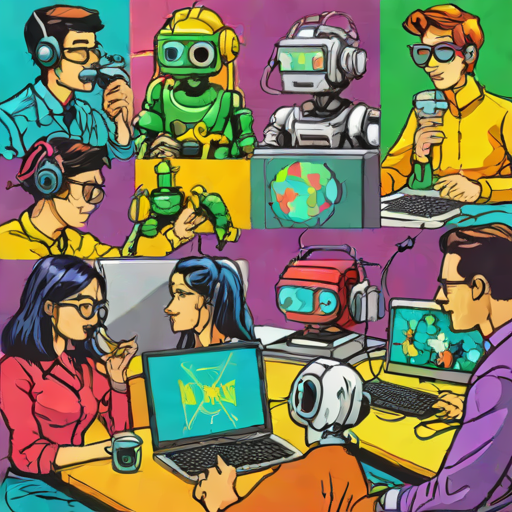

In [27]:
# Image Generation
# Pipelines can be used for diffusion models as well as transformers

from IPython.display import display
from diffusers import AutoPipelineForText2Image # pipeline khusus text-to-image dari diffusers dan torch
import torch

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16") # mengatur presisi angka ke float16(16-bit) lebih ringan/hemat memori daripada 32-bit standar, variant="fp16" -> minta versi model yang memang di optimalkan untuk float16
pipe.to("cuda") # memindahkan model ke GPU, sebelumnya di dalam pipeline(), disini caranya 2 langkah, buat pipeline() dulu baru .to("cuda")
prompt = "A class of students learning AI engineering in a vibrant pop-art style"
image = pipe(prompt=prompt, num_inference_steps=4, guidance_scale=0.0).images[0] # menjalankan pipeline untuk generate image dan argument nya, num_inference_steps=4 (atur beberapa tahap "pembersihan noise"), guidance_scale=0.0 (mengatur seberapa ketat model mengikuti prompt, set 0.0 karena memang begitu rekomendasinya), images[0] (jumlah image yang di generate, bisa lebih dari satu image)
display(image)

In [2]:
# Apa itu embedding ?
# embedding : cara mengubah sesuatu(kata,kalimat,image,suara) menjadi deretan angka yang menangkap "makna" nya
# Komputer tidak mengerti kata "kucing" atau seseorang, yang di mengerti cuma angka, Embedding adalah jembatannya: ia menerjemahkan makna jadi sebuah daftar angka(vektor) misal [0.2, -0.5, 0.8, 0.1, ...] yang bisa panjangnya ratusan angka.
# Contoh untuk kata:

# "kucing" → [0.2, 0.9, ...]
# "anjing" → [0.3, 0.8, ...] ← dekat dengan kucing (sama-sama hewan peliharaan)
# "mobil" → [-0.7, 0.1, ...] ← jauh dari keduanya
# jadi embedding mengubah "makna" jadi "posisi ruang angka", hal yang bermakna serupa akan berdekatan posisinya
# case ini embedding di pakai adalah speaker embedding untuk suara

# Batch : sekumpulan data yang di proses model sekaligus dalam satu waktu
# misal : memproses 32 kalimat sekaligus
# konsekuensinya : model selalu mengharapkan input dalam bentuk batch, walaupun hanya punya satu data, model tetap ingin dia di bungkus sebagai "batch"

# .unsqueeze(0) mengubah "satu embedding" jadi "batch berisi satu embedding"
# .unsqueeze(0) menambah dimensi = membungkus angka dengan kurung baru jadi [[..]], mengubah bentuk tanpa mengubah nilai

from transformers import pipeline
from datasets import load_dataset # library intuk memuat karakter suara
import soundfile as sf
import torch
from IPython.display import Audio

synthesiser = pipeline("text-to-speech", "microsoft/speecht5_tts", device="cuda") # membuat pipeline task "text-to-speech" + "model" + "pindahkan ke GPU"
embeddings_dataset = load_dataset("matthijs/cmu-arctic-xvectors", split="validation", trust_remote_code=True) # memuat sebuah dataset berisi "speaker embedding", yaitu kumpulan "sidik suara" dari berbagai penutur, "matthijs/cmu-arctic-xvectors": nama dataset nya, split="validation": ambil bagian "validation" dari dataset, trust_remote_code=True: izinkan menjalankan code dari dataset ini
speaker_embedding = torch.tensor(embeddings_dataset[7306]["xvector"]).unsqueeze(0) # menyiapkan karakter suara yang akan di pakai: embeddings_dataset[7306]["xvector"] -> mengambil embedding penutur nomor [7306] dari katalog, angka hanyalah katalog, bisa ganti angka untuk suara yang berbeda. torch.tensor(...) -> mengubah data jadi tensor(format angka yang di mengerti model), torch sebagai machine deep learning untuk membungkus data. .unsqueeze(0) -> menambah satu "dimensi" pada tensor, detail teknis model mengharapkan data dalam bentuk batch,
speech = synthesiser("Hi to an artificial intelligence engineer, on the way to mastery", forward_params={"speaker_embeddings": speaker_embedding}) # menjalankan TTS dua input: 1. "teks yang di ucapkan", 2. memberikan karakter suara yang di siapkan, ini menentukan suara siapa yang akan di gunakan, tanpa ini model tidak tau harus pakai suara seperti apa

Audio(speech['audio'], rate=speech["sampling_rate"]) # menampilkan pemutaran audio di notebook: speech['audio'] data gelombang suara, speech=["sampling_rate"] berapa banyak sample suara per detik(menentukan kualitas/kecepatan pemutaran). rate= memberitahu pemutar cara memutarnya dengan benar

# Alur
# buat pipeline -> panggil dengan input(speaker_embedding) -> proses embedding -> output suara

Device set to use cuda


spkrec-xvect.zip:   0%|          | 0.00/17.9M [00:00<?, ?B/s]

Generating validation split: 0 examples [00:00, ? examples/s]